Using device: cuda
Epoch 50, Loss: -0.6422203183174133
Epoch 100, Loss: -1.0418399572372437
Epoch 150, Loss: 2.5124526023864746
Epoch 200, Loss: -0.9011984467506409
Epoch 250, Loss: -1.4679830074310303
Epoch 300, Loss: -1.6812607049942017
Epoch 350, Loss: -0.7124443650245667
Epoch 400, Loss: -1.341124176979065
Epoch 450, Loss: -2.6765291690826416
Epoch 500, Loss: 0.603097140789032
Final samples shape: (200000, 6)
Final data_tensor shape: torch.Size([70000, 7])
Generated 200000 valid samples.


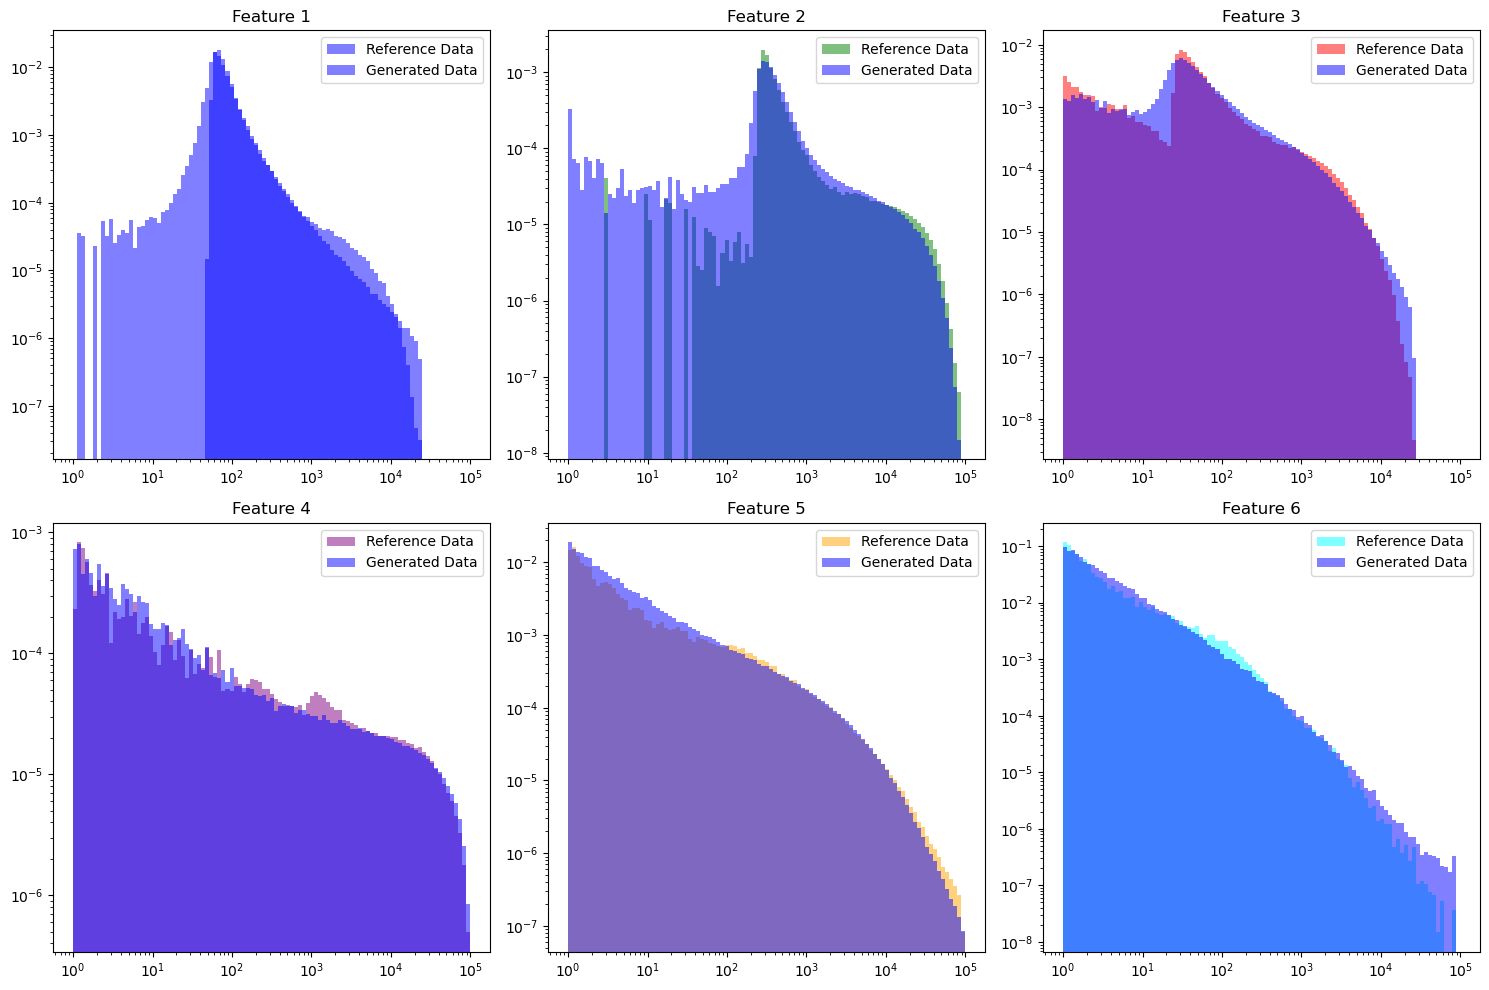

In [1]:
import numpy as np  
import h5py
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation
import time
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ALPHA = 1e-6

def logit(x):
    return torch.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit(local_x)


def inverse_logit(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

start_time = time.time()

# load and preprocess data
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data + 'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

# combine energy & layers
data = np.hstack((energy.reshape(-1, 1), E_layers))

# replace inf with NaN for filterning
data[np.isinf(data)] = np.nan
# remove rows with NaN values
valid_mask = ~np.isnan(data).any(axis=1)
data = data[valid_mask]

# convert to tensor
data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

# normalize and logit transform todo: f einc PREP1
data_max = data_tensor.max(dim=0).values
data_tensor = data_tensor / data_max
data_tensor = logit_trafo(data_tensor)

# debug
if torch.isnan(data_tensor).any() or torch.isinf(data_tensor).any():
    raise ValueError("Data tensor contains NaN or Inf values after transformations.")

# remove nan and inf
mask = ~torch.isnan(data_tensor).any(dim=1) & ~torch.isinf(data_tensor).any(dim=1)
data_tensor = data_tensor[mask]

# normalize to zero mean and unit variance (?)todo: einc PREP2
data_mean = data_tensor.mean(dim=0)
data_std = data_tensor.std(dim=0)
data_tensor = (data_tensor - data_mean) / data_std

# split the data tensor into context feature and training features
context_feature = data_tensor[:, 0].unsqueeze(1)  # context
input_features = data_tensor[:, 1:]  #layer features

# define flow model
num_layers = 5 #todo:  6-10
base_distribution = StandardNormal(shape=[input_features.shape[1]])  # shape matches input featurs (excl. context)
transforms = []

for _ in range(num_layers):
    #permutation to shuffle features
    transforms.append(ReversePermutation(features=input_features.shape[1]))
    # Add the MaskedAffineAutoregressiveTransform with context features #transforms.MaskedPiecewiseRationalQuadraticAutoregressiveTransform statt maskedaffineautoreg.. 
    transforms.append(MaskedAffineAutoregressiveTransform(
        features=input_features.shape[1],  # exclude the context feature (corr?)
        hidden_features=64,
        context_features=1  # context is one feature (first column) (corr?)
    ))

transform = CompositeTransform(transforms)
flow = Flow(transform, base_distribution).to(device)

# train the flow model
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
num_epochs = 500 #orig 500, nur zu testzwecken kleiner gesetzt
batch_size = 256
best_loss = float('inf')

#TODO: torch data set/ dataloader - from torch. utils. data import dataloader
# Initialize best model path
best_model_path = "best_flow_model.pth"
for epoch in range(num_epochs):
    # shuffle data
    idx = torch.randperm(len(data_tensor))
    data_tensor = data_tensor[idx]

    # split data into context and input features
    context_feature = data_tensor[:, 0].unsqueeze(1)  # 1. spalte
    input_features = data_tensor[:, 1:]  # remaining columns

    for i in range(0, len(input_features), batch_size):
        # create batches for input and context
        batch_inputs = input_features[i:i + batch_size]
        batch_context = context_feature[i:i + batch_size]

        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()

        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            optimizer.step()
            best_loss = min(best_loss, loss.item())
            
        # Update best model
       # if loss.item() < best_loss:
          #  best_loss = loss.item()
           # torch.save(flow.state_dict(), best_model_path)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

        
#flow.load_state_dict(torch.load(best_model_path, weights_only=True))
import torch.nn.functional as F

# generate samples
n_samples = len(data_tensor)
n_samples = 200000
batch_size = 1000
all_samples = []

# Preprocess Einc using the same steps as the training data (corr?)
Einc_gen = torch.rand((n_samples,1)).to(device) *99+1 # todo: separat speichern
Einc_gen = Einc_gen / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]  # standardize



# context is expanded for each batch
with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        current_batch_size = min(batch_size, n_samples - i)  #last batch otherwise prod. error
       # batch_context = Einc.repeat(current_batch_size, 1)
        #n split um batches mit einc
        batch_context = Einc_gen[i:i+batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()

        all_samples.append(samples_batch)

# since all samples now same size -> cat
samples = torch.cat(all_samples, dim=0)#100000,6


samples = samples *data_std[1:].cpu()+ data_mean[1:].cpu() 
samples = inverse_logit(samples)
samples = samples * data_max[1:].cpu()
samples = samples.squeeze().numpy()
   
# Final adjustment if needed
print(f"Final samples shape: {samples.shape}")
print(f"Final data_tensor shape: {data_tensor.shape}")
print(f"Generated {len(samples)} valid samples.")

# histogramme
#num_features = data.shape[1] 
#fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
#axs = axs.flatten()


colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']
# ensure samples are valid before plotting
#if torch.isnan(samples).any() or torch.isinf(samples).any():
 #   raise ValueError("Samples contain NaN or Inf values before plotting.")

# exclude the context feature (first column of data)
# histogramme
num_features = data.shape[1] - 1
fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
axs = axs.flatten()


colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(num_features): 
    #bins = 500 if len(data[:, i+1]) > 500 else len(data[:, i+1])  
    bins = np.logspace(0, 5, 100)
    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1],  #exclude context feature
        bins=bins,
        alpha=0.5,
        label="Reference Data",
        color=colors[i % len(colors)],  
        density=True,
        log=True
    )
    axs[i].hist(
        samples[:, i],
        bins=bin_edges,
        alpha=0.5,
        label="Generated Data",
        color='blue',  
        density=True,
        log=True
    )
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")  

for j in range(len(axs)):
    if j >= num_features:
        axs[j].axis('off')

plt.tight_layout()
plt.show()

In [2]:
#CLASSIFIER
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy

real_data = data_tensor.cpu().numpy()
generated_data = samples

# Create labels
smallest_size = min(len(real_data), len(generated_data))

# Randomly select smallest_size indices
real_indices = np.random.choice(len(real_data), smallest_size, replace=False)
generated_indices = np.random.choice(len(generated_data), smallest_size, replace=False)

# Select only those samples
real_data = real_data[real_indices]
generated_data = generated_data[generated_indices]

print(f"Final real data shape: {real_data.shape}")
print(f"Final gen shape: {generated_data.shape}")

real_labels = np.ones(len(real_data))  
maf_labels = np.zeros(len(generated_data))

# combining of real and KDE gen data
combined_data = np.vstack((real_data[:, 1:], generated_data))
combined_labels = np.hstack((real_labels, maf_labels))

# split into trainning and test sets
X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42)

#CLASSIFIER SETUP
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.round(outputs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_preds = []
    all_labels = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.round(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds)
    print('Accuracy: {:.4f}, AUC (area under roc curve): {:.4f}'.format(acc, auc))
    return acc, auc

# dataloader setup
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)
}

# Model, criterion, optimizer
input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train & evaluate
model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
evaluate_model(model, dataloaders)
end_time = time.time()
elapsed_time = end_time - start_time
hours, rem = divmod(elapsed_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total time taken: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

Final real data shape: (70000, 7)
Final gen shape: (70000, 6)
Epoch number 0/24
----------
train Loss: 50.0401 Acc: 0.4987
val Loss: 49.6607 Acc: 0.5034
Epoch number 1/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 2/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 3/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 4/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 5/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 6/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 7/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 8/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 9/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 10/24
---------

data_max_reg[0] = 99.99932861328125
E_inc=10 GeV: mean error = -0.07, std = 2.45, sat = 0.01%, time = 33.93s
  Bin fraction at true energy: 26.46%
  FWHM: 3.57 GeV
E_inc=20 GeV: mean error = 0.22, std = 3.62, sat = 0.03%, time = 34.03s
  Bin fraction at true energy: 15.40%
  FWHM: 7.14 GeV
E_inc=30 GeV: mean error = 0.53, std = 4.50, sat = 0.01%, time = 34.01s
  Bin fraction at true energy: 13.59%
  FWHM: 8.33 GeV
E_inc=40 GeV: mean error = 0.67, std = 5.19, sat = 0.02%, time = 34.04s
  Bin fraction at true energy: 11.29%
  FWHM: 10.71 GeV
E_inc=50 GeV: mean error = 0.92, std = 5.98, sat = 0.02%, time = 34.13s
  Bin fraction at true energy: 8.32%
  FWHM: 11.90 GeV
E_inc=60 GeV: mean error = 0.91, std = 6.56, sat = 0.06%, time = 34.01s
  Bin fraction at true energy: 9.32%
  FWHM: 9.52 GeV
E_inc=70 GeV: mean error = 1.11, std = 7.00, sat = 0.27%, time = 34.11s
  Bin fraction at true energy: 6.93%
  FWHM: 11.90 GeV
E_inc=80 GeV: mean error = 0.91, std = 7.12, sat = 0.95%, time = 33.95s
  

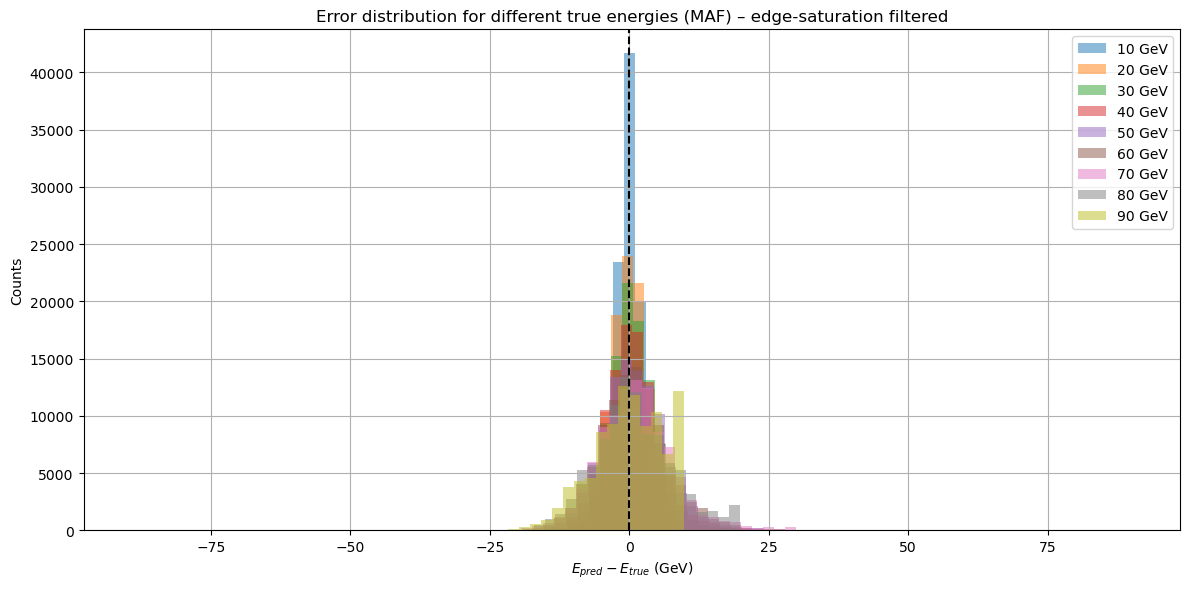

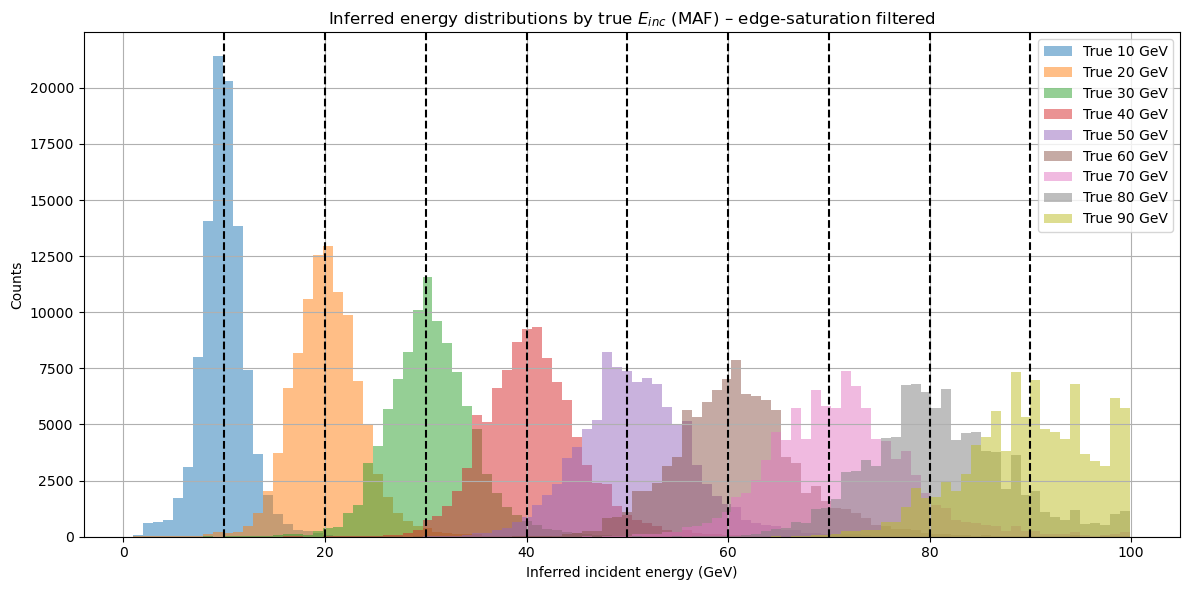


=== Per-energy regression summary (edge-saturation filtered) ===
E_true [GeV]        N   Bias [GeV]  MAE [GeV]  RMSE [GeV]  Std [GeV]  68% width [GeV]  Sat. frac
        10    99987       -0.068      1.690       2.447      2.446            3.861      0.01%
        20    99972        0.217      2.653       3.625      3.618            6.336      0.03%
        30    99992        0.525      3.294       4.534      4.503            7.821      0.01%
        40    99981        0.672      3.820       5.232      5.188            9.009      0.02%
        50    99979        0.923      4.500       6.055      5.985           10.494      0.02%
        60    99936        0.913      4.900       6.625      6.562           11.286      0.06%
        70    99730        1.108      5.329       7.083      6.996           12.573      0.27%
        80    99052        0.909      5.476       7.177      7.119           13.761      0.95%
        90    97356       -0.164      5.095       6.427      6.425           

In [8]:
# =========================
# REGRESSION EVALUATION (MAF) – multi-energy scan WITH TIMING + EDGE-SATURATION FIX
# =========================
import os
import time
import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))   # 10,20,...,90

# Choose scan range with margin so true energies aren't at the scan boundary
Emin = 1.0
Emax = 120.0          # margin above 90; avoids true energy sitting at boundary
num_scan_points = 1000
batch_size = 10000

errors_by_energy = {}
inferred_by_energy = {}       # store inferred distributions per energy (after filtering)
sat_frac_by_energy = {}       # store saturation fraction per energy

# --- logit helpers (same as training) ---
def logit_reg(x):
    return torch.log(x / (1.0 - x))

def logit_trafo_reg(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x,
                          min=1e-6, max=1 - 1e-6)
    return logit_reg(local_x)

def inverse_logit_reg(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

# --- Load + preprocess test data ---
def load_and_preprocess_test_file(filepath, data_mean_reg, data_std_reg, data_max_reg, device):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    data = data[~np.isnan(data).any(axis=1)]

    x = torch.tensor(data, dtype=torch.float32, device=device)
    x = x / data_max_reg
    x = logit_trafo_reg(x)
    x = (x - data_mean_reg) / data_std_reg

    return x[:, 1:]   # only layers

# --- Energy inference via likelihood scan ---
# Returns inferred energies AND argmax indices to detect edge saturation.
def infer_incident_energy(flow, layer_tensor,
                          data_mean_reg, data_std_reg, data_max_reg,
                          num_scan_points=1000, Emin=1.0, Emax=120.0,
                          batch_size=10000):

    device = layer_tensor.device
    n_samples = layer_tensor.shape[0]

    #E_candidates = torch.linspace(Emin, Emax, num_scan_points,
    #                              device=device).view(-1, 1)

    # scan only within training support to avoid logit clamp plateau
    Emax_eff = float(data_max_reg[0].item()) * 0.999
    E_candidates = torch.linspace(Emin, Emax_eff, num_scan_points,device=device).view(-1, 1)
    # preprocess candidates EXACTLY like training column 0
    E_norm  = E_candidates / data_max_reg[0]
    E_logit = logit_trafo_reg(E_norm)
    E_std   = (E_logit - data_mean_reg[0]) / data_std_reg[0]

    E_context = E_std.view(1, -1, 1).repeat(n_samples, 1, 1)
    inputs    = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)

    flat_inputs  = inputs.view(-1, inputs.shape[-1])
    flat_context = E_context.view(-1, 1)

    log_probs_list = []
    flow.eval()
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            logp = flow.log_prob(flat_inputs[i:i+batch_size],
                                 context=flat_context[i:i+batch_size])
            log_probs_list.append(logp)

    log_probs = torch.cat(log_probs_list).view(n_samples, num_scan_points)
    max_indices = log_probs.argmax(dim=1)

    inferred_E = E_candidates[max_indices].squeeze(1).cpu().numpy()
    return inferred_E, max_indices.cpu().numpy()

# --- move training stats to device ---
data_mean_reg = data_mean.to(device)
data_std_reg  = data_std.to(device)
data_max_reg  = data_max.to(device)
flow = flow.to(device)

print("data_max_reg[0] =", float(data_max_reg[0].item()))
Emax_eff = float(data_max_reg[0].item()) * 0.999


# =========================
# START TIMING
# =========================
reg_start_time = time.time()

# --- Loop over true energies ---
for E_true in energy_values:
    t0 = time.time()

    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')
    layer_tensor = load_and_preprocess_test_file(
        file_path, data_mean_reg, data_std_reg, data_max_reg, device
    )

    inferred, max_idx = infer_incident_energy(
        flow, layer_tensor,
        data_mean_reg, data_std_reg, data_max_reg,
        num_scan_points=num_scan_points, Emin=Emin, Emax=Emax, batch_size=batch_size
    )

    # --- EDGE SATURATION FIX ---
    sat = (max_idx == 0) | (max_idx == (num_scan_points - 1))
    sat_frac = float(sat.mean())
    sat_frac_by_energy[E_true] = sat_frac  # FIX: store INSIDE the loop

    inferred_clean = inferred[~sat]
    if len(inferred_clean) == 0:
        inferred_clean = inferred
        print("  WARNING: all events saturated; keeping unfiltered inferred values for this energy.")

    error = inferred_clean - E_true
    errors_by_energy[E_true] = error
    inferred_by_energy[E_true] = inferred_clean

    print(f"E_inc={E_true} GeV: mean error = {np.mean(error):.2f}, std = {np.std(error):.2f}, "
          f"sat = {sat_frac:.2%}, time = {time.time() - t0:.2f}s")

    # --- Histogram diagnostics (on CLEAN inferred) ---
    counts, bin_edges = np.histogram(inferred_clean, bins=100, range=(Emin, Emax))
    bin_idx = np.digitize([E_true], bin_edges)[0] - 1
    bin_idx = max(0, min(bin_idx, len(counts) - 1))

    ratio_true_bin = counts[bin_idx] / counts.sum() if counts.sum() > 0 else 0.0
    print(f"  Bin fraction at true energy: {ratio_true_bin:.2%}")

    # FWHM estimate from histogram (CLEAN inferred)
    max_count = counts.max() if counts.size > 0 else 0
    half_max = max_count / 2 if max_count > 0 else 0
    above_half = np.where(counts >= half_max)[0] if max_count > 0 else np.array([])

    if len(above_half) > 0:
        fwhm = bin_edges[above_half[-1] + 1] - bin_edges[above_half[0]]
    else:
        fwhm = 0.0

    print(f"  FWHM: {fwhm:.2f} GeV")

# =========================
# END TIMING
# =========================
reg_end_time = time.time()
reg_elapsed = reg_end_time - reg_start_time
h, rem = divmod(reg_elapsed, 3600)
m, s = divmod(rem, 60)
print(f"\nTotal regression time: {int(h)}h {int(m)}m {s:.2f}s")

# =========================
# PLOTS
# =========================

# Plot 1: Error distributions (CLEAN; saturated events removed)
plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(error, bins=50, alpha=0.5, label=f"{E_true} GeV")
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("$E_{pred} - E_{true}$ (GeV)")
plt.ylabel("Counts")
plt.title("Error distribution for different true energies (MAF) – edge-saturation filtered")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Inferred energy distributions (use inferred_clean directly)
plt.figure(figsize=(12, 6))
for E_true, inferred_clean in inferred_by_energy.items():
    #plt.hist(inferred_clean, bins=100, range=(Emin, Emax), alpha=0.5, label=f"True {E_true} GeV")
    plt.hist(inferred_clean, bins=100, range=(Emin, Emax_eff), alpha=0.5, label=f"True {E_true} GeV")
    plt.axvline(E_true, color='black', linestyle='--')
plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (MAF) – edge-saturation filtered")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# FINAL REGRESSION SUMMARY (over all energies)
# =========================
summary_rows = []

all_errors = []
all_rel_errors = []
total_n = 0

for E_true in energy_values:
    err = np.asarray(errors_by_energy[E_true]).reshape(-1)

    n = len(err)
    total_n += n
    all_errors.append(err)

    rel_err = err / E_true
    all_rel_errors.append(rel_err)

    bias = float(np.mean(err))
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    std  = float(np.std(err))

    q16, q50, q84 = np.quantile(err, [0.16, 0.50, 0.84])
    width68 = float(q84 - q16)

    sat = sat_frac_by_energy.get(E_true, np.nan)

    summary_rows.append({
        "E_true [GeV]": E_true,
        "N": n,
        "Bias [GeV]": bias,
        "MAE [GeV]": mae,
        "RMSE [GeV]": rmse,
        "Std [GeV]": std,
        "Median [GeV]": float(q50),
        "68% width [GeV]": width68,
        "Sat. frac": float(sat)
    })

all_errors = np.concatenate(all_errors) if len(all_errors) else np.array([])
all_rel_errors = np.concatenate(all_rel_errors) if len(all_rel_errors) else np.array([])

if len(all_errors) > 0:
    global_bias = float(np.mean(all_errors))
    global_mae  = float(np.mean(np.abs(all_errors)))
    global_rmse = float(np.sqrt(np.mean(all_errors**2)))
    global_std  = float(np.std(all_errors))

    gq16, gq50, gq84 = np.quantile(all_errors, [0.16, 0.50, 0.84])
    global_width68 = float(gq84 - gq16)

    global_rel_mae = float(np.mean(np.abs(all_rel_errors)))
    global_rel_rmse = float(np.sqrt(np.mean(all_rel_errors**2)))
else:
    global_bias = global_mae = global_rmse = global_std = np.nan
    global_width68 = global_rel_mae = global_rel_rmse = np.nan

print("\n=== Per-energy regression summary (edge-saturation filtered) ===")
header = ["E_true [GeV]", "N", "Bias [GeV]", "MAE [GeV]", "RMSE [GeV]", "Std [GeV]", "68% width [GeV]", "Sat. frac"]
print("{:>10} {:>8} {:>12} {:>10} {:>11} {:>10} {:>16} {:>10}".format(*header))
for r in summary_rows:
    print("{:>10.0f} {:>8d} {:>12.3f} {:>10.3f} {:>11.3f} {:>10.3f} {:>16.3f} {:>10.2%}".format(
        r["E_true [GeV]"], r["N"], r["Bias [GeV]"], r["MAE [GeV]"], r["RMSE [GeV]"],
        r["Std [GeV]"], r["68% width [GeV]"], r["Sat. frac"]
    ))

print("\n=== Global regression summary (all energies pooled) ===")
print(f"Total N: {total_n}")
print(f"Bias  [GeV]: {global_bias:.3f}")
print(f"MAE   [GeV]: {global_mae:.3f}")
print(f"RMSE  [GeV]: {global_rmse:.3f}")
print(f"Std   [GeV]: {global_std:.3f}")
print(f"68% width [GeV]: {global_width68:.3f}")
print(f"Relative MAE  [%]: {100*global_rel_mae:.3f}")
print(f"Relative RMSE [%]: {100*global_rel_rmse:.3f}")

